In [1]:
import pandas as pd #판다스 패키지 불러오기
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sys

pd.set_option("display.max_columns", None) #모든 열을 보여줌
plt.rc('font', family='Malgun Gothic')

C:\Users\USER\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\USER\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
data_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/데이터셋/'
image_path = 'C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/시각화/'
train_loan_df = pd.read_csv(data_path+'loan_df_train.csv')
log_df = pd.read_csv(data_path+'/log_df(전처리 완).csv')
user_activity_df = pd.read_csv(data_path+'user_activity_df2.csv')

# 이탈률 분석

## 1-1. 전체 유저 이탈률 분석

In [3]:
user_breakaway=user_activity_df.groupby('user_id').agg(
total_loan_apply =('대출 한도조회 횟수(수)','sum'),
total_breakaway1 =('이탈 유형1(수)','sum'),
total_breakaway2 =('이탈 유형2(수)','sum'))

user_breakaway['이탈률'] = user_breakaway.iloc[:,1:3].sum(axis=1)/user_breakaway.sum(axis=1)
user_breakaway['이탈 유형1 비율'] = user_breakaway['total_breakaway1'] /user_breakaway.iloc[:,1:3].sum(axis=1)
user_breakaway['이탈 유형2 비율'] = user_breakaway['total_breakaway2'] /user_breakaway.iloc[:,1:3].sum(axis=1)
user_breakaway = user_breakaway.reset_index()

In [4]:
# 조회된 신청서별 대출 신청 유무
loan_apply_sum = train_loan_df.groupby(['신청서_id','유저_id','나이'])['신청여부'].sum()
loan_apply_sum = loan_apply_sum.apply(lambda x : 1 if x >=1 else 0)
loan_apply_sum = pd.DataFrame(loan_apply_sum).reset_index()

In [6]:
user_breakaway = user_breakaway.rename(columns={'user_id':'유저_id'})

apply_breakaway = pd.merge(loan_apply_sum,user_breakaway[['유저_id','이탈률', '이탈 유형1 비율', '이탈 유형2 비율']],how='left',on='유저_id')
apply_breakaway['연령대'] = (apply_breakaway['나이']+1)//10

### 1-1-1. 이탈성향에 따른 대출 신청 연관성 분석

In [69]:
apply_ratio['total_apply'].describe()

count    259328.000000
mean          2.810664
std           3.988783
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max         267.000000
Name: total_apply, dtype: float64

In [7]:
# 이탈률 0인 유저 , 0이아닌 유저
apply_breakaway['이탈성향'] = 'heavy'
apply_breakaway.loc[apply_breakaway['이탈률']!=0,'이탈성향']='light'

# 전체 신청서 수 count
apply_ratio = apply_breakaway.groupby(['유저_id','이탈성향']).agg(
total_apply = ('신청서_id','count'),
real_apply=('신청여부','sum'),
breakaway_ratio = ('이탈률','mean'))
apply_ratio = apply_ratio.reset_index() 

print(apply_ratio['이탈성향'].value_counts())

apply_ratio = apply_ratio.loc[apply_ratio['total_apply']>2,:]

print(apply_ratio.loc[apply_ratio['이탈성향']=='heavy','real_apply'].sum(axis=0)/apply_ratio.loc[apply_ratio['이탈성향']=='heavy','total_apply'].sum(axis=0))
print(apply_ratio.loc[apply_ratio['이탈성향']=='light','real_apply'].sum(axis=0)/apply_ratio.loc[apply_ratio['이탈성향']=='light','total_apply'].sum(axis=0))

apply_ratio['대출 신청률'] = apply_ratio['real_apply']/apply_ratio['total_apply']

print(apply_ratio.loc[apply_ratio['이탈성향']=='heavy','대출 신청률'].describe())
print(apply_ratio.loc[apply_ratio['이탈성향']=='light','대출 신청률'].describe())

이탈성향
light    232595
heavy     26733
Name: count, dtype: int64
0.56926722566533
0.5040552478956883
count    2900.000000
mean        0.580197
std         0.333241
min         0.000000
25%         0.333333
50%         0.666667
75%         1.000000
max         1.000000
Name: 대출 신청률, dtype: float64
count    77701.000000
mean         0.549724
std          0.309780
min          0.000000
25%          0.333333
50%          0.600000
75%          0.750000
max          1.000000
Name: 대출 신청률, dtype: float64


Text(0.5, 1.0, '이탈 성향에 따른 대출 신청률')

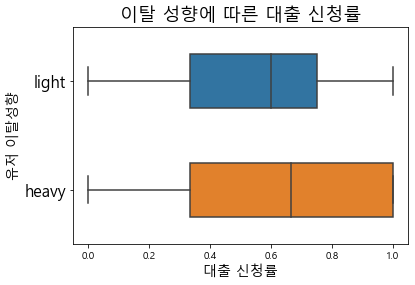

In [7]:
import matplotlib.pyplot as plt
import seaborn as sys

plt.figure(figsize=(6, 4))
ax = sys.boxplot(data=apply_ratio, x='대출 신청률', y='이탈성향', width=0.5)
plt.xlabel('대출 신청률',fontsize=14)  # y축 글자 크기
plt.ylabel('유저 이탈성향',fontsize=14)  # y축 글자 크기

# y축 카테고리 글자 크기 조정
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)  

# 제목 추가
plt.title("이탈 성향에 따른 대출 신청률", fontsize=18)  # 제목과 글자 크기 설정
#plt.savefig(image_path+"이탈 성향에 따른 대출 신청률_boxplot.png")  # PNG 형식으로 저장

In [8]:
from scipy.stats import levene

# 두 집단으로 데이터 나누기
heavy_group = apply_ratio[apply_ratio['이탈성향'] == 'heavy']['대출 신청률']
light_group = apply_ratio[apply_ratio['이탈성향'] == 'light']['대출 신청률']

# Levene's test 실행
stat, p_value = levene(heavy_group, light_group)
print(f"Levene's test p-value: {p_value}")  # 분산이 동일하지 않다고 판단 (등분산 가정 X)

Levene's test p-value: 4.269964188256829e-06


In [9]:
# 두 집단의 분산이 같지 않으므로,  Welch’s t-test 검정 수행  ( 같을 경우, Student's t-test)

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(apply_ratio.loc[apply_ratio['이탈성향']=='heavy','대출 신청률']
                            , apply_ratio.loc[apply_ratio['이탈성향']=='light','대출 신청률'], equal_var=False)

print(f"t-statistic: {t_stat}, p-value: {p_value}")

t-statistic: 4.846885169548716, p-value: 1.3160409238065423e-06


### 1-1-2. 유형별 이탈률과 대출 신청 연관분석

In [8]:
# light 유저들의 전체 신청서 수와 실제 신청한 횟수 구하기
apply_ratio2 = apply_breakaway.loc[apply_breakaway['이탈성향']=='light'].groupby(['유저_id','이탈 유형1 비율','이탈 유형2 비율']).agg(
total_apply = ('신청서_id','count'),
real_apply=('신청여부','sum'))
apply_ratio2 = apply_ratio2.reset_index() 

apply_ratio2 = apply_ratio2.loc[apply_ratio2['total_apply']>2,:]

apply_ratio2['대출 신청률'] = apply_ratio2['real_apply']/apply_ratio2['total_apply']

<AxesSubplot:xlabel='이탈 유형2 비율'>

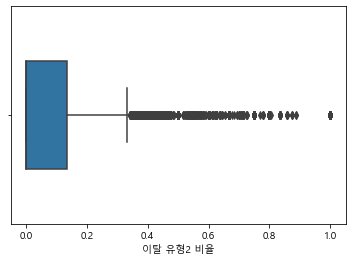

In [11]:
sys.boxplot(data=apply_ratio2, x='이탈 유형2 비율', width=0.5)
#plt.savefig(image_path+"이탈 유형2 비율_boxplot.png")  # PNG 형식으로 저장

In [9]:
def convert_breakaway_ratio(x):
    if x<0.1:
        return '정상'
    elif x>=0.1 and x<0.3:
        return '불편함'
    elif x>=0.3 and x<0.5:
        return '조금 부정적'
    elif x>=0.5 and x<0.7:
        return '부정적'
    else:
        return '매우 부정적'

apply_ratio2['Step3 부정경험'] = apply_ratio2['이탈 유형2 비율'].apply(lambda x : convert_breakaway_ratio(x) )

In [13]:
print(apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='정상','real_apply'].sum(axis=0)/apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='정상','total_apply'].sum(axis=0))
print(apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='불편함','real_apply'].sum(axis=0)/apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='불편함','total_apply'].sum(axis=0))
print(apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='조금 부정적','real_apply'].sum(axis=0)/apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='조금 부정적','total_apply'].sum(axis=0))
print(apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='부정적','real_apply'].sum(axis=0)/apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='부정적','total_apply'].sum(axis=0))
print(apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='매우 부정적','real_apply'].sum(axis=0)/apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='매우 부정적','total_apply'].sum(axis=0))

0.5143792804849249
0.4908040709387889
0.4736554473269682
0.47998132368390334
0.4803472770323599


In [14]:
print(apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='정상','대출 신청률'].describe())
print(apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='불편함','대출 신청률'].describe())
print(apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='조금 부정적','대출 신청률'].describe())
print(apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='부정적','대출 신청률'].describe())
print(apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='매우 부정적','대출 신청률'].describe())

count    53626.000000
mean         0.558658
std          0.311531
min          0.000000
25%          0.333333
50%          0.600000
75%          0.800000
max          1.000000
Name: 대출 신청률, dtype: float64
count    15232.000000
mean         0.541088
std          0.299032
min          0.000000
25%          0.333333
50%          0.555556
75%          0.750000
max          1.000000
Name: 대출 신청률, dtype: float64
count    4293.000000
mean        0.523218
std         0.303078
min         0.000000
25%         0.304348
50%         0.500000
75%         0.750000
max         1.000000
Name: 대출 신청률, dtype: float64
count    2929.000000
mean        0.518897
std         0.310576
min         0.000000
25%         0.285714
50%         0.500000
75%         0.750000
max         1.000000
Name: 대출 신청률, dtype: float64
count    1283.000000
mean        0.501394
std         0.326811
min         0.000000
25%         0.250000
50%         0.500000
75%         0.750000
max         1.000000
Name: 대출 신청률, dtype: float64

In [10]:
from scipy.stats import f_oneway
from scipy.stats import levene
#import pingouin as pg

group1 = apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='정상','대출 신청률']
group2 = apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='불편함','대출 신청률']
group3 =apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='조금 부정적','대출 신청률']
group4 =apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='부정적','대출 신청률']
group5 =apply_ratio2.loc[apply_ratio2['Step3 부정경험']=='매우 부정적','대출 신청률']

# Levene's test 실행  
stat, p_value = levene(group1, group2, group3, group4, group5)
print(f"Levene's test p-value: {p_value}")  # 등분산성 만족 X

# Welch's ANOVA 실행
#welch_anova = pg.welch_anova(dv='대출 신청률', between='Step3 부정경험', data=apply_ratio)
#print(welch_anova)

# ANOVA 검정
f_stat, p_value = f_oneway(group1, group2, group3, group4, group5)

print(f"F-statistic: {f_stat}, p-value: {p_value}")


Levene's test p-value: 4.657429795345824e-13
F-statistic: 37.0189402583228, p-value: 5.635768755730163e-31


Text(0.5, 1.0, 'Step3 부정경험에 따른 대출 신청률')

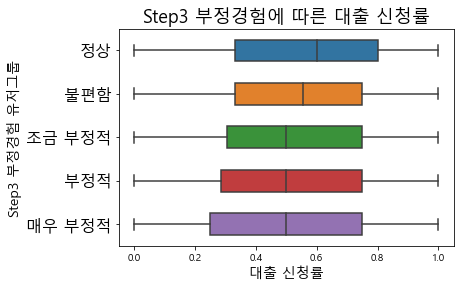

In [17]:
order = ['정상', '불편함' , '조금 부정적', '부정적', '매우 부정적']
ax = sys.boxplot(data=apply_ratio2, x='대출 신청률', y='Step3 부정경험', width=0.5,order=order)
plt.xlabel('대출 신청률',fontsize=14)  # y축 글자 크기
plt.ylabel('Step3 부정경험 유저그룹',fontsize=14)  # y축 글자 크기

# y축 카테고리 글자 크기 조정
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)  

# 제목 추가
plt.title("Step3 부정경험에 따른 대출 신청률", fontsize=18)  # 제목과 글자 크기 설정
#plt.savefig(image_path+"Step3 부정경험 유저별 대출신청률_boxplot.png")  # PNG 형식으로 저장

Text(0.5, 1.0, 'Step3 부정경험에 따른 평균 대출 신청률')

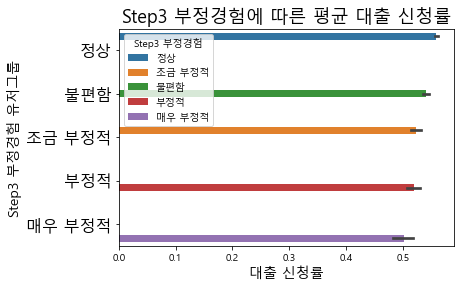

In [18]:
ax = sys.barplot(data=apply_ratio2, x="대출 신청률", y="Step3 부정경험", hue="Step3 부정경험",order=order)
plt.xlabel('대출 신청률',fontsize=14)  # y축 글자 크기
plt.ylabel('Step3 부정경험 유저그룹',fontsize=14)  # y축 글자 크기
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16) 
plt.title("Step3 부정경험에 따른 평균 대출 신청률", fontsize=18)
#plt.savefig(image_path+"Step3 부정경험 유저별 대출신청률_barplot.png")  # PNG 형식으로 저장

## 부정경험 유저별 EDA

In [226]:
order = ['정상', '불편함' , '조금 부정적', '부정적', '매우 부정적']


group_df = pd.merge(train_loan_df,apply_ratio2[['유저_id','Step3 부정경험']],
                   how='inner',on='유저_id')
group_df.head()

,신청서_id,한도조회일시,금융사_id,상품_id,승인한도,승인금리,신청여부,유저_id,성별,연소득,근로형태,고용형태,주거소유형태,대출희망금액,대출목적,신용등급,나이,개인회생,기대출수유무,Step3 부정경험
0,576643,2022-05-09 10:54:53,54,235,11000000.0,16.5,0.0,545882.0,1.0,72000000.0,0.0,0.0,0.0,20000000.0,0.0,7.0,45.0,0.0,1.0,정상
1,576643,2022-05-09 10:54:53,11,118,3000000.0,20.0,0.0,545882.0,1.0,72000000.0,0.0,0.0,0.0,20000000.0,0.0,7.0,45.0,0.0,1.0,정상
2,2136706,2022-05-09 10:41:06,42,216,10000000.0,13.5,0.0,558819.0,1.0,39000000.0,0.0,0.0,0.0,80000000.0,1.0,5.0,39.0,0.0,1.0,정상
3,2136706,2022-05-09 10:41:07,25,169,22000000.0,15.9,0.0,558819.0,1.0,39000000.0,0.0,0.0,0.0,80000000.0,1.0,5.0,39.0,0.0,1.0,정상
4,2136706,2022-05-09 10:41:07,22,221,10000000.0,18.4,0.0,558819.0,1.0,39000000.0,0.0,0.0,0.0,80000000.0,1.0,5.0,39.0,0.0,1.0,정상


In [227]:
group_df = group_df.drop_duplicates(subset=['유저_id'], keep='first').reset_index(drop=True)

In [213]:
freq_table = pd.crosstab(group_df["Step3 부정경험"], group_df["대출목적"])
freq_table_row_pct = freq_table.div(freq_table.sum(axis=1), axis=0) * 100
print(freq_table_row_pct)


대출목적              0.0        1.0       2.0       3.0       4.0       5.0  \
Step3 부정경험                                                                 
매우 부정적      70.303975  17.381138  4.754482  1.714731  1.792673  1.558846   
부정적         65.619665  22.669853  5.223626  1.877774  1.809491  1.194947   
불편함         62.618172  27.094275  4.181985  2.173057  1.680672  0.873162   
정상          59.525230  29.002723  4.803640  2.252639  1.831201  1.221422   
조금 부정적      65.269043  23.736315  4.262753  2.026555  1.840205  1.164687   

대출목적             6.0       7.0  
Step3 부정경험                      
매우 부정적      1.948558  0.545596  
부정적         1.058382  0.546262  
불편함         0.958508  0.420168  
정상          1.059188  0.303957  
조금 부정적      1.467505  0.232937  


In [212]:
freq_table = pd.crosstab(group_df["Step3 부정경험"], group_df["신용등급"])
freq_table_row_pct = freq_table.div(freq_table.sum(axis=1), axis=0) * 100
print(freq_table_row_pct)

신용등급            1.0       2.0       3.0       4.0        5.0        6.0   \
Step3 부정경험                                                                 
매우 부정적      2.338270  3.663289  5.300078  6.703040  10.522214  18.784100   
부정적         2.560601  3.653124  4.813930  7.818368  13.929669  21.611471   
불편함         1.851366  2.580095  3.853729  6.748950  13.228729  26.030725   
정상          2.349607  3.160780  4.479171  7.507552  13.939134  27.313244   
조금 부정적      2.445842  3.517354  4.239460  7.197764  12.974610  25.343583   

신용등급             7.0       8.0       9.0       10.0  
Step3 부정경험                                           
매우 부정적      49.961029  2.572097  0.155885  0.000000  
부정적         41.789006  3.516559  0.238989  0.068283  
불편함         41.504727  3.840599  0.216649  0.144433  
정상          38.017007  2.964980  0.154776  0.113751  
조금 부정적      39.878873  3.983229  0.256231  0.163056  


In [231]:
freq_table = pd.crosstab(group_df["Step3 부정경험"], group_df["기대출수유무"])
freq_table_row_pct = freq_table.div(freq_table.sum(axis=1), axis=0) * 100
print(freq_table_row_pct)

기대출수유무            0.0        1.0
Step3 부정경험                      
매우 부정적      45.985970  54.014030
부정적         21.201775  78.798225
불편함          6.184349  93.815651
정상           8.113602  91.886398
조금 부정적      12.229210  87.770790


In [228]:
user_avg_durations = user_avg_durations.rename(columns={'user_id':'유저_id'})

#group_df = pd.merge(group_df , user_avg_durations ,how = 'left', on = '유저_id')
temp_duration = group_df.dropna(subset=['session_duration'])

<AxesSubplot:xlabel='Step3 부정경험', ylabel='session_duration'>

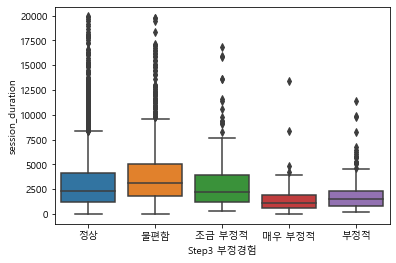

In [230]:
import seaborn as sys

sys.boxplot(data=temp_duration.loc[temp_duration['session_duration']<20000], x="Step3 부정경험", y="session_duration")

<AxesSubplot:xlabel='Step3 부정경험', ylabel='나이'>

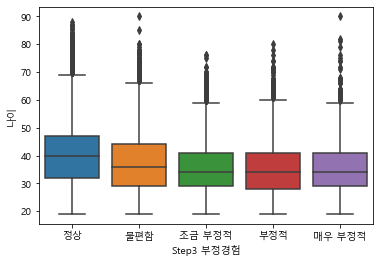

In [209]:
import seaborn as sys

sys.boxplot(data=group_df, x="Step3 부정경험", y="나이")

<AxesSubplot:xlabel='Step3 부정경험', ylabel='연소득'>

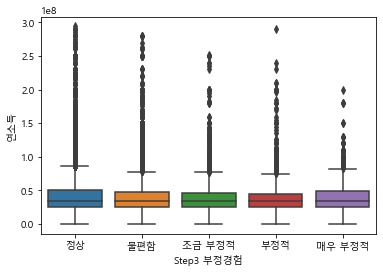

In [206]:
import seaborn as sys

sys.boxplot(data=group_df.loc[group_df['연소득']<3e8], x="Step3 부정경험", y="연소득")

## 유저 그룹화

### 전체 유저

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

group_df = group_df.drop_duplicates(subset=['유저_id'], keep='first').reset_index(drop=True)

# 그룹화 
grouping_cols = ['연소득','신용등급', '나이','기대출수유무','대출희망금액']
group = group_df.loc[:,grouping_cols]
# 데이터 스케일링 (중요!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(group)

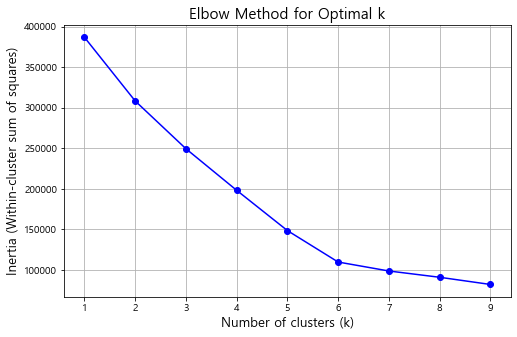

In [177]:
# Elbow Method를 위한 inertia 값 계산
inertia = []

# 클러스터 개수 1~10까지 반복
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Elbow Plot 그리기
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)', fontsize=13)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=13)
plt.title('Elbow Method for Optimal k', fontsize=15)
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [178]:
# 클러스터 개수 지정 (예시: 3)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# 군집화 결과 확인
group['cluster'] = kmeans.labels_
print(group.head())
print(group['cluster'].value_counts())

          연소득  신용등급    나이  기대출수유무      대출희망금액  cluster
0  72000000.0   7.0  45.0     1.0  20000000.0        5
1  39000000.0   5.0  39.0     1.0  80000000.0        0
2  29000000.0   6.0  37.0     1.0  50000000.0        0
3  28000000.0   7.0  30.0     1.0   2000000.0        0
4  31000000.0   7.0  28.0     1.0   3000000.0        0
cluster
0    34214
5    25169
2    10905
1     7018
3       32
4       25
Name: count, dtype: int64


<AxesSubplot:xlabel='cluster', ylabel='연소득'>

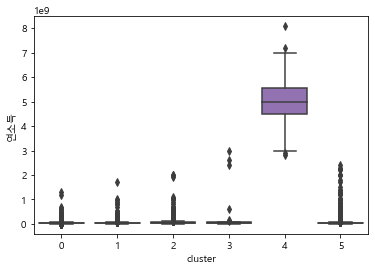

In [179]:
import seaborn as sys

sys.boxplot(data=group, x="cluster", y="연소득")

<AxesSubplot:xlabel='cluster', ylabel='연소득'>

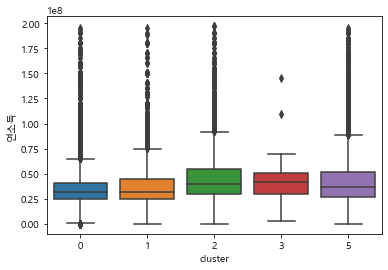

In [191]:
import seaborn as sys

sys.boxplot(data=group.loc[(group['cluster']!=4) & (group['연소득']<2e8) ,:], x="cluster", y="연소득")

In [198]:
temp = group_df.loc[group.loc[group['cluster']==4,:].index,'근로형태']
temp.value_counts()/len(temp)

근로형태
0.0    0.64
1.0    0.12
3.0    0.08
5.0    0.08
2.0    0.08
Name: count, dtype: float64

<AxesSubplot:xlabel='cluster', ylabel='대출희망금액'>

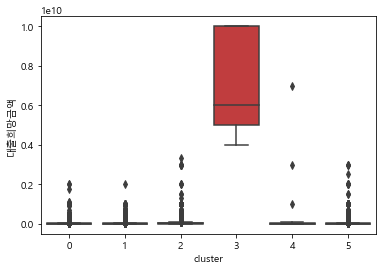

In [181]:
import seaborn as sys

sys.boxplot(data=group, x="cluster", y="대출희망금액")

<AxesSubplot:xlabel='cluster', ylabel='대출희망금액'>

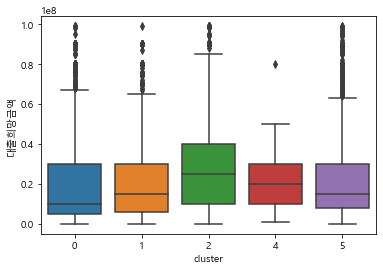

In [196]:
import seaborn as sys

sys.boxplot(data=group.loc[(group['cluster']!=3) & (group['대출희망금액']<1e8) ,:], x="cluster", y="대출희망금액")

In [199]:
temp = group_df.loc[group.loc[group['cluster']==3,:].index,'근로형태']
temp.value_counts()/len(temp)

근로형태
0.0    0.87500
4.0    0.06250
1.0    0.03125
2.0    0.03125
Name: count, dtype: float64

<AxesSubplot:xlabel='cluster', ylabel='신용등급'>

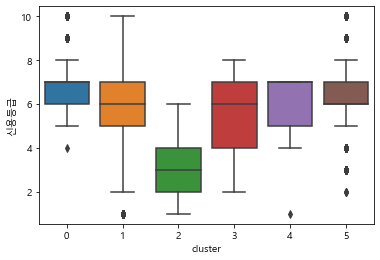

In [183]:
import seaborn as sys

sys.boxplot(data=group, x="cluster", y="신용등급")

In [200]:
temp = group_df.loc[group.loc[group['cluster']==2,:].index,'근로형태']
temp.value_counts()/len(temp)

근로형태
0.0    0.701421
2.0    0.120220
1.0    0.081981
3.0    0.053278
4.0    0.031453
5.0    0.011646
Name: count, dtype: float64

<AxesSubplot:xlabel='cluster', ylabel='나이'>

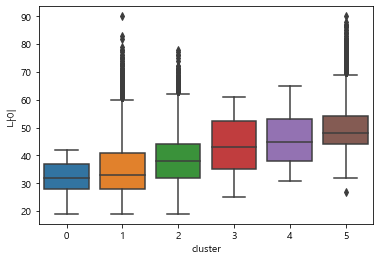

In [184]:
import seaborn as sys

sys.boxplot(data=group, x="cluster", y="나이")

<AxesSubplot:xlabel='cluster', ylabel='기대출수유무'>

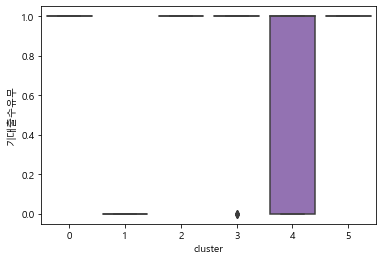

In [189]:
import seaborn as sys

sys.boxplot(data=group, x="cluster", y="기대출수유무")

In [197]:
group_df.loc[group.loc[group['cluster']==1,:].index,'대출목적'].value_counts()

대출목적
0.0    4568
1.0    1226
2.0     482
4.0     229
3.0     192
5.0     147
6.0     124
7.0      50
Name: count, dtype: int64

### 매우 부정적 그룹( Roust 표준화)

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

#group_df = group_df.drop_duplicates(subset=['유저_id'], keep='first').reset_index(drop=True)

# 그룹화 
grouping_cols = ['연소득','신용등급', '나이','기대출수유무']
group5 = group_df.loc[group_df["Step3 부정경험"]=='매우 부정적',grouping_cols]
# 데이터 스케일링 (중요!)
scaler = RobustScaler()
X_scaled5 = scaler.fit_transform(group5)

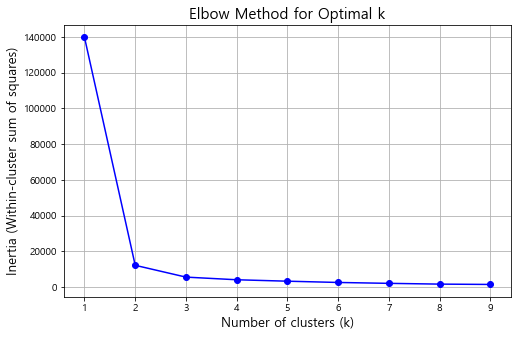

In [101]:
# Elbow Method를 위한 inertia 값 계산
inertia5 = []

# 클러스터 개수 1~10까지 반복
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled5)
    inertia5.append(kmeans.inertia_)

# Elbow Plot 그리기
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia5, 'bo-')
plt.xlabel('Number of clusters (k)', fontsize=13)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=13)
plt.title('Elbow Method for Optimal k', fontsize=15)
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [102]:
# 클러스터 개수 지정 (예시: 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# 군집화 결과 확인
group5['cluster'] = kmeans.labels_
print(group5.head())

            연소득  신용등급    나이  기대출수유무  cluster
56   36000000.0   6.0  27.0     1.0        0
322  50000000.0   4.0  82.0     1.0        0
401  31000000.0   5.0  22.0     1.0        0
478  24000000.0   7.0  40.0     1.0        0
482  37000000.0   7.0  29.0     0.0        0


In [103]:
group5['cluster'].value_counts()

cluster
0    1276
2       4
1       3
Name: count, dtype: int64

<AxesSubplot:xlabel='cluster', ylabel='연소득'>

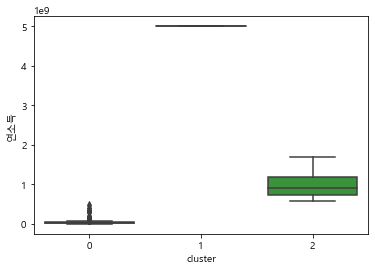

In [104]:
import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="연소득")

<AxesSubplot:xlabel='cluster', ylabel='신용등급'>

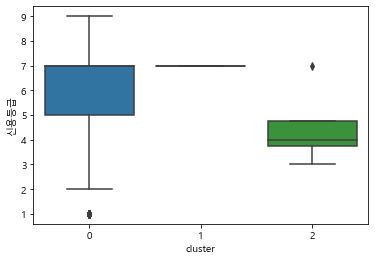

In [92]:
import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="신용등급")

<AxesSubplot:xlabel='cluster', ylabel='나이'>

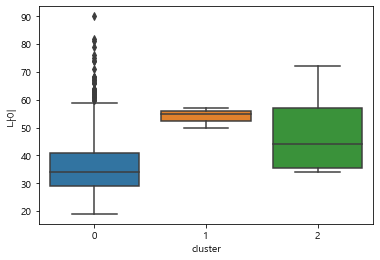

In [93]:
import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="나이")

<AxesSubplot:xlabel='cluster', ylabel='기대출수유무'>

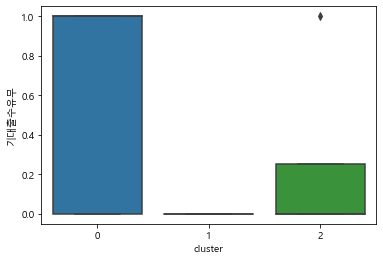

In [94]:
import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="기대출수유무")

### 매우 부정적 그룹( standard 표준화)

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

#group_df = group_df.drop_duplicates(subset=['유저_id'], keep='first').reset_index(drop=True)

# 그룹화 
grouping_cols = ['연소득','신용등급', '나이','기대출수유무','대출희망금액']
group5 = group_df.loc[group_df["Step3 부정경험"]=='매우 부정적',grouping_cols]
# 데이터 스케일링 (중요!)
scaler = StandardScaler()
X_scaled5 = scaler.fit_transform(group5)

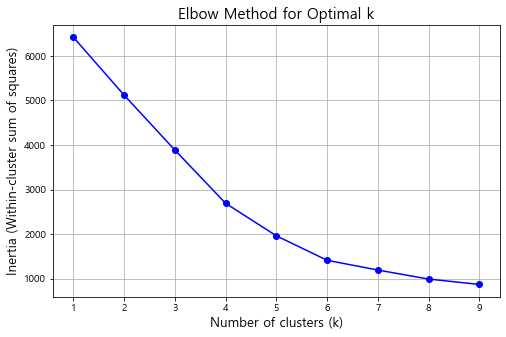

In [142]:
# Elbow Method를 위한 inertia 값 계산
inertia = []

# 클러스터 개수 1~10까지 반복
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled5)
    inertia.append(kmeans.inertia_)

# Elbow Plot 그리기
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)', fontsize=13)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=13)
plt.title('Elbow Method for Optimal k', fontsize=15)
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [143]:
# 클러스터 개수 지정 (예시: 3)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_scaled5)

# 군집화 결과 확인
group5['cluster'] = kmeans.labels_
print(group5.head())

            연소득  신용등급    나이  기대출수유무      대출희망금액  cluster
56   36000000.0   6.0  27.0     1.0   1000000.0        2
322  50000000.0   4.0  82.0     1.0  20000000.0        1
401  31000000.0   5.0  22.0     1.0  24000000.0        2
478  24000000.0   7.0  40.0     1.0  30000000.0        2
482  37000000.0   7.0  29.0     0.0  10000000.0        0


In [144]:
group5['cluster'].value_counts()

cluster
2    563
0    485
1    231
4      3
3      1
Name: count, dtype: int64

<AxesSubplot:xlabel='cluster', ylabel='대출희망금액'>

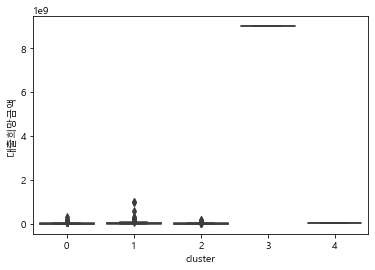

In [152]:
import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="대출희망금액")

<AxesSubplot:xlabel='cluster', ylabel='대출희망금액'>

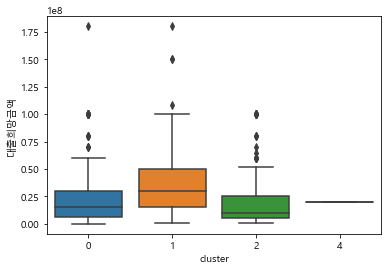

In [173]:
import seaborn as sys

sys.boxplot(data=group5.loc[(group5['cluster']!=3) & (group5['대출희망금액']<2e8) ,:], x="cluster", y="대출희망금액")

<AxesSubplot:xlabel='cluster', ylabel='연소득'>

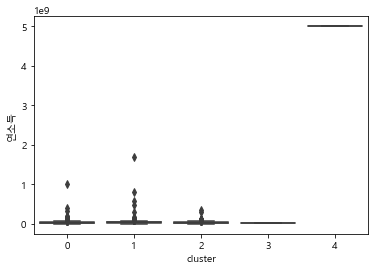

In [145]:
import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="연소득")

<AxesSubplot:xlabel='cluster', ylabel='연소득'>

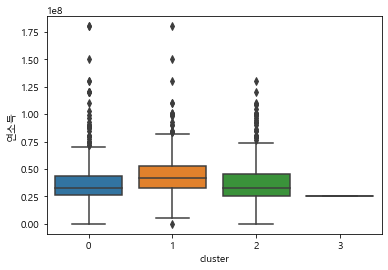

In [148]:
import seaborn as sys

sys.boxplot(data=group5.loc[(group5['cluster']!=4) & (group5['연소득']<2e8) ,:], x="cluster", y="연소득")

<AxesSubplot:xlabel='cluster', ylabel='신용등급'>

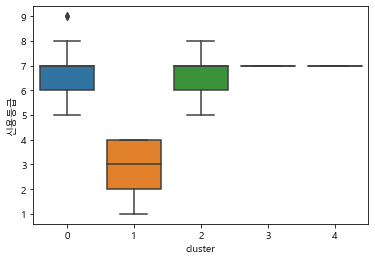

In [149]:
import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="신용등급")

In [174]:
temp = group_df.loc[group5.loc[group5['cluster']==4].index,'대출목적']
temp.value_counts()/len(temp)

대출목적
0.0    1.0
Name: count, dtype: float64

<AxesSubplot:xlabel='cluster', ylabel='나이'>

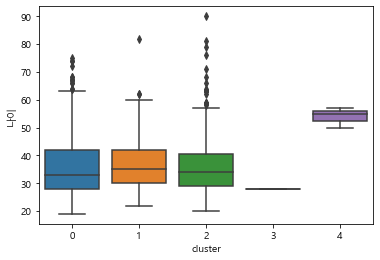

In [175]:
import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="나이")

<AxesSubplot:xlabel='cluster', ylabel='기대출수유무'>

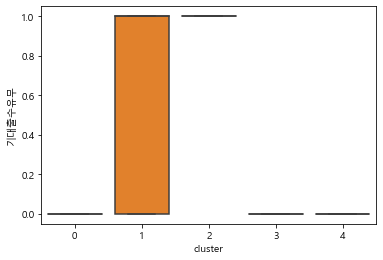

In [151]:
import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="기대출수유무")

In [ ]:
### 매우 부정적 그룹( Roust 표준화)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

group_df = group_df.drop_duplicates(subset=['유저_id'], keep='first').reset_index(drop=True)

# 그룹화 
grouping_cols = ['연소득','신용등급', '나이','기대출수유무']
group5 = group_df.loc[group_df["Step3 부정경험"]=='매우 부정적',grouping_cols]
# 데이터 스케일링 (중요!)
scaler = RobustScaler()
X_scaled5 = scaler.fit_transform(group5)

# Elbow Method를 위한 inertia 값 계산
inertia = []

# 클러스터 개수 1~10까지 반복
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled5)
    inertia.append(kmeans.inertia_)

# Elbow Plot 그리기
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)', fontsize=13)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=13)
plt.title('Elbow Method for Optimal k', fontsize=15)
plt.xticks(k_range)
plt.grid(True)
plt.show()


# 클러스터 개수 지정 (예시: 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# 군집화 결과 확인
group5['cluster'] = kmeans.labels_
print(group5.head())

group5['cluster'].value_counts()

import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="연소득")

import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="신용등급")

import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="나이")

import seaborn as sys

sys.boxplot(data=group5, x="cluster", y="기대출수유무")
# UMAP으로 차원 축소
import umap.umap_ as umap
import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap='tab10', s=50)
plt.colorbar()
plt.title('UMAP Clustering Visualization', fontsize=15)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=13)
plt.grid(True)
plt.show()

### 2. 매우 부정적 + 부정적 그룹

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# 그룹화 
grouping_cols = ['연소득','신용등급', '나이','기대출수유무']
group45 = group_df.loc[group_df["Step3 부정경험"].isin(['매우 부정적','부정적']),grouping_cols]
# 데이터 스케일링 (중요!)
scaler = StandardScaler()
X_scaled45 = scaler.fit_transform(group45)

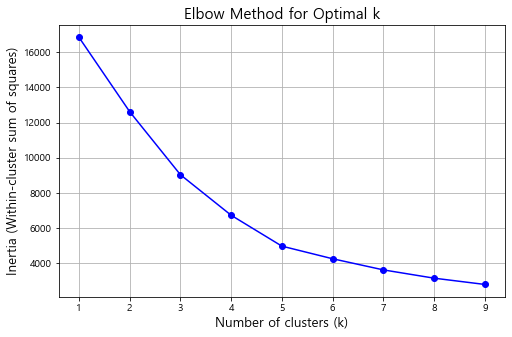

In [59]:
# Elbow Method를 위한 inertia 값 계산
inertia45 = []

# 클러스터 개수 1~10까지 반복
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled45)
    inertia45.append(kmeans.inertia_)

# Elbow Plot 그리기
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia45, 'bo-')
plt.xlabel('Number of clusters (k)', fontsize=13)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=13)
plt.title('Elbow Method for Optimal k', fontsize=15)
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [60]:
# 클러스터 개수 지정 (예시: 3)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled45)

# 군집화 결과 확인
group45['cluster'] = kmeans.labels_
print(group45.head())

            연소득  신용등급    나이  기대출수유무  cluster
13   37000000.0   4.0  34.0     1.0        0
42    1000000.0   5.0  35.0     1.0        2
50   22000000.0   7.0  46.0     1.0        2
56   36000000.0   6.0  27.0     1.0        2
122  30000000.0   7.0  28.0     1.0        2


In [65]:
group45['cluster'].value_counts()

cluster
2    2447
1    1064
0     698
3       3
Name: count, dtype: int64

<AxesSubplot:xlabel='cluster', ylabel='연소득'>

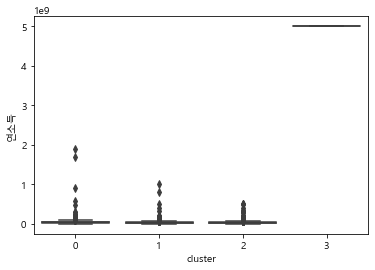

In [61]:
import seaborn as sys

sys.boxplot(data=group45, x="cluster", y="연소득")

<AxesSubplot:xlabel='cluster', ylabel='신용등급'>

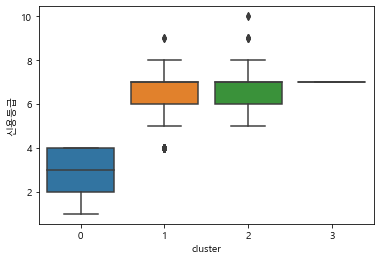

In [62]:
import seaborn as sys

sys.boxplot(data=group45, x="cluster", y="신용등급")

<AxesSubplot:xlabel='cluster', ylabel='나이'>

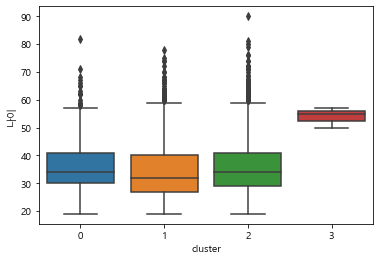

In [63]:
import seaborn as sys

sys.boxplot(data=group45, x="cluster", y="나이")

<AxesSubplot:xlabel='cluster', ylabel='기대출수유무'>

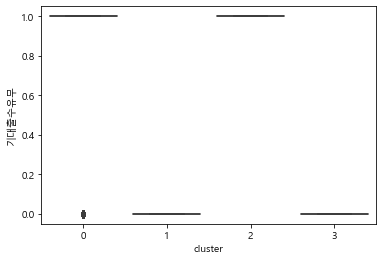

In [64]:
import seaborn as sys

sys.boxplot(data=group45, x="cluster", y="기대출수유무")

# 유저별 평균 체류시간
- 세션 평균 체류시간 => 12.7초
- 0초를 제외한 유저별 평균 세션 체류시간 계산

In [214]:
# timestamp 속성으로 변환
log_df['timestamp'] = pd.to_datetime(log_df['timestamp'])
# 세션별 체류 시간 계산  
session_durations = log_df.groupby(['user_id','session_id']).agg(
    session_start=('timestamp', 'min'),
    session_end=('timestamp', 'max')
)
# session_duration (세션별 체류시간)  
session_durations['session_duration'] = (session_durations['session_end'] - session_durations['session_start']).dt.total_seconds()

# 체류시간이 0인 세션 제외
filtered_sessions = session_durations[session_durations['session_duration'] > 0]

# 유저별 총 체류 시간 계산
user_avg_durations = filtered_sessions.groupby('user_id')['session_duration'].sum().reset_index()
user_avg_durations = pd.DataFrame(user_avg_durations)

In [215]:
def seconds_to_hms(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    seconds = int(seconds % 60)
    return f"{hours}시 {minutes}분 {seconds}초"

# 변환 적용
user_avg_durations['평균 체류시간'] = user_avg_durations['session_duration'].apply(seconds_to_hms)

#user_avg_durations.to_csv(data_path+'유저별_평균체류시간.csv',index=False)

In [67]:
# 유저별 대출신청 df와 병합
user_avg_durations = user_avg_durations.rename(columns={'user_id':'유저_id'})
user_avg_durations = pd.merge(apply_ratio[['유저_id','total_apply','real_apply','대출 신청률']],user_avg_durations,how='left',on='유저_id')
user_avg_durations = user_avg_durations.dropna(axis=0)

In [68]:
# 대출 신청 유무로 그룹 분리
applied_group = user_avg_durations.loc[user_avg_durations['real_apply']==0,'session_duration']
non_applied_group = user_avg_durations.loc[user_avg_durations['real_apply']!=0,'session_duration']

print(applied_group.mean())
print(non_applied_group.mean())

user_avg_durations['대출 신청여부']=user_avg_durations['real_apply'].apply(lambda x : 'non_apply' if x==0 else 'apply')

894.1652962260173
2199.814068692206


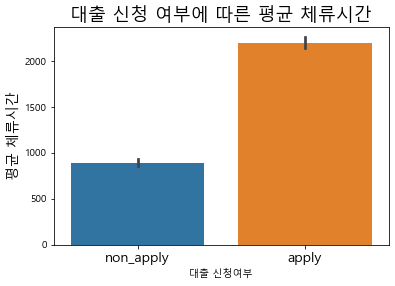

In [70]:
ax = sys.barplot(data = user_avg_durations, x="대출 신청여부", y="session_duration")
plt.ylabel('평균 체류시간',fontsize=14)  # y축 글자 크기

# y축 카테고리 글자 크기 조정
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  

# 제목 추가
plt.title("대출 신청 여부에 따른 평균 체류시간", fontsize=18)  # 제목과 글자 크기 설정
#plt.savefig(image_path+"대출 신청 여부에 따른 평균 체류시간_barplot.png")  # PNG 형식으로 저장

In [71]:
print(user_avg_durations['session_duration'].describe())
print(user_avg_durations['session_duration'].quantile(0.05))
print(user_avg_durations['session_duration'].quantile(0.95))

count    16855.000000
mean      1832.404272
std       2855.203391
min          1.000000
25%        372.500000
50%        948.000000
75%       2252.000000
max      76868.000000
Name: session_duration, dtype: float64
92.0
6238.299999999999


# 유저별 앱 사용성

In [197]:
apply_cnt_df = user_avg_durations[['유저_id','real_apply']]

,유저_id,total_apply,real_apply,대출 신청률,session_duration,평균 체류시간,대출 신청여부
0,9.0,1,0,0.000000,335.0,0시 5분 35초,non_apply
1,11.0,2,2,1.000000,1687.0,0시 28분 7초,apply
3,17.0,2,2,1.000000,620.0,0시 10분 20초,apply
4,19.0,1,0,0.000000,89.0,0시 1분 29초,non_apply
5,20.0,6,5,0.833333,1275.0,0시 21분 15초,apply
...,...,...,...,...,...,...,...
19392,65473.0,7,2,0.285714,1468.0,0시 24분 28초,apply
19393,65483.0,2,2,1.000000,2530.0,0시 42분 10초,apply
19394,65488.0,1,0,0.000000,1471.0,0시 24분 31초,non_apply
19395,65489.0,5,1,0.200000,1164.0,0시 19분 24초,apply


In [202]:
# 대출 신청 여부별 유저그룹 추출
applied_user = user_avg_durations.loc[user_avg_durations['real_apply']!=0,'유저_id']
non_applied_user = user_avg_durations.loc[user_avg_durations['real_apply']==0,'유저_id']

In [211]:
# 유저별 전체 이벤트 수 count
user_activity_sum = user_activity_df.groupby('user_id').sum()
user_activity_sum = user_activity_sum.drop('session_id',axis=1)
user_activity_sum = user_activity_sum.reset_index()

user_activity_sum['대출 신청여부'] = 'applied'
user_activity_sum.loc[user_activity_sum['user_id'].isin(non_applied_user),'대출 신청여부']='non_apply'
user_activity_sum['전체 활동수'] = user_activity_sum.iloc[:,[1,4,5,6]].sum(axis=1)

In [212]:
user_activity_sum['대출조회_비율'] = user_activity_sum['대출 한도조회 횟수(수)']/user_activity_sum['전체 활동수']
user_activity_sum['대출관리_비율'] = user_activity_sum['대출관리서비스(수)']/user_activity_sum['전체 활동수']
user_activity_sum['여윳돈 계산기_비율'] = user_activity_sum['여윳돈 계산기(수)']/user_activity_sum['전체 활동수']
user_activity_sum['DSR 계산기_비율'] = user_activity_sum['DSR 계산기(수)']/user_activity_sum['전체 활동수']

In [206]:
category = ['대출 조회','대출관리서비스','여윳돈 계산기','DSR 계산기']
colnames=['대출조회_비율', '대출관리_비율', '여윳돈 계산기_비율', 'DSR 계산기_비율']
values1 = [user_activity_sum.loc[user_activity_sum['대출 신청여부']=='applied',col].mean() for col in colnames ]
values2 = [user_activity_sum.loc[user_activity_sum['대출 신청여부']!='applied',col].mean() for col in colnames ]

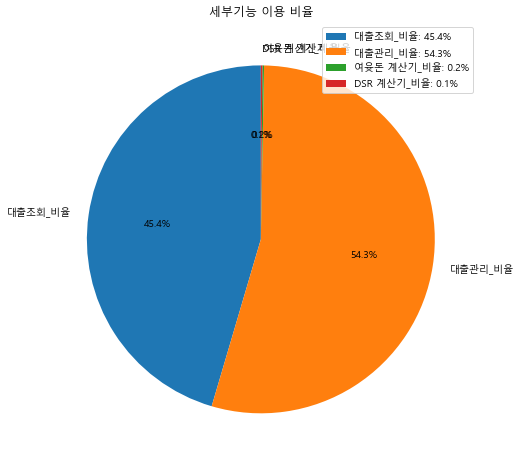

<Figure size 432x288 with 0 Axes>

In [207]:
# 파이 차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(
    values1,  # 데이터 값
    labels=colnames,  # 범주 이름
    autopct='%1.1f%%',  # 비율 표시
    startangle=90,  # 시작 각도
    #colors=['#ff9999', '#66b3ff', '#99ff99'],  # 색상
    #shadow=True  # 그림자 효과
)
base_labels=[]
for label, size in zip(colnames,values1):
    base_labels.append(f"{label}: {round((size/sum(values1))*100,1)}%")


plt.legend([*base_labels], loc="upper right", bbox_to_anchor=(1, 1))

plt.title("세부기능 이용 비율")  # 제목
plt.show()
plt.savefig(image_path+"_barplot.png")  # PNG 형식으로 저장

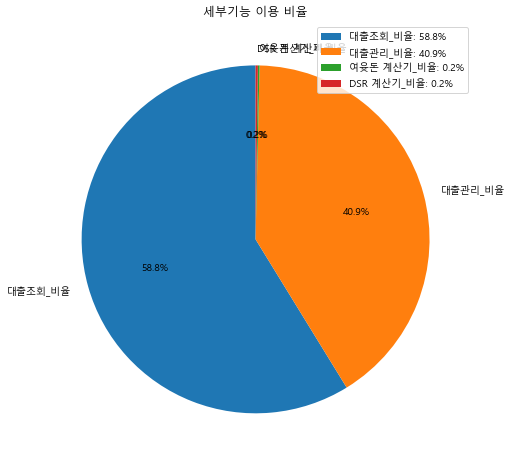

In [208]:
# 파이 차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(
    values2,  # 데이터 값
    labels=colnames,  # 범주 이름
    autopct='%1.1f%%',  # 비율 표시
    startangle=90,  # 시작 각도
    #colors=['#ff9999', '#66b3ff', '#99ff99'],  # 색상
    #shadow=True  # 그림자 효과
)
base_labels=[]
for label, size in zip(colnames,values2):
    base_labels.append(f"{label}: {round((size/sum(values2))*100,1)}%")


plt.legend([*base_labels], loc="upper right", bbox_to_anchor=(1, 1))

plt.title("세부기능 이용 비율")  # 제목
plt.show()


In [213]:
apply_cnt_df = user_avg_durations[['유저_id','real_apply']]
user_activity_sum = user_activity_sum.rename(columns={'user_id':'유저_id'})
user_activity_sum = pd.merge(user_activity_sum,apply_cnt_df,how='inner',on='유저_id')
user_activity_sum

,유저_id,대출 한도조회 횟수(수),대출한도 전체 조회(수),신용조회(수),대출관리서비스(수),여윳돈 계산기(수),DSR 계산기(수),이탈 유형1(수),이탈 유형2(수),대출 신청여부,전체 활동수,대출조회_비율,대출관리_비율,여윳돈 계산기_비율,DSR 계산기_비율,real_apply
0,9,0,0,0,0,0,0,1,0,non_apply,0,NaN,NaN,NaN,NaN,0
1,11,4,6,0,7,1,0,8,0,applied,12,0.333333,0.583333,0.083333,0.0,2
2,17,2,4,0,1,0,0,2,0,applied,3,0.666667,0.333333,0.000000,0.0,2
3,19,1,1,0,0,0,0,0,0,non_apply,1,1.000000,0.000000,0.000000,0.0,0
4,20,6,10,0,0,0,0,4,0,applied,6,1.000000,0.000000,0.000000,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16846,65473,8,11,0,2,0,0,2,0,applied,10,0.800000,0.200000,0.000000,0.0,2
16847,65483,10,16,0,4,0,0,6,3,applied,14,0.714286,0.285714,0.000000,0.0,2
16848,65488,1,1,0,17,0,0,23,0,non_apply,18,0.055556,0.944444,0.000000,0.0,0
16849,65489,5,6,0,3,0,0,3,0,applied,8,0.625000,0.375000,0.000000,0.0,1


In [216]:
user_activity_sum[['real_apply','대출조회_비율', '대출관리_비율', '여윳돈 계산기_비율', 'DSR 계산기_비율']].corr()

,real_apply,대출조회_비율,대출관리_비율,여윳돈 계산기_비율,DSR 계산기_비율
real_apply,1.000000,0.046920,-0.045707,-0.007051,-0.023502
대출조회_비율,0.046920,1.000000,-0.997376,-0.084652,-0.066943
대출관리_비율,-0.045707,-0.997376,1.000000,0.028116,0.009841
여윳돈 계산기_비율,-0.007051,-0.084652,0.028116,1.000000,0.234794
DSR 계산기_비율,-0.023502,-0.066943,0.009841,0.234794,1.000000


In [214]:
user_activity_sum

Index(['유저_id', '대출 한도조회 횟수(수)', '대출한도 전체 조회(수)', '신용조회(수)', '대출관리서비스(수)',
       '여윳돈 계산기(수)', 'DSR 계산기(수)', '이탈 유형1(수)', '이탈 유형2(수)', '대출 신청여부',
       '전체 활동수', '대출조회_비율', '대출관리_비율', '여윳돈 계산기_비율', 'DSR 계산기_비율',
       'real_apply'],
      dtype='object')

# 대출시점 이전 1주일간 방문횟수

In [93]:
train_loan_df2.head()

,신청서_id,한도조회일시,금융사_id,상품_id,승인한도,승인금리,신청여부,유저_id,성별,연소득,근로형태,고용형태,주거소유형태,대출희망금액,대출목적,신용등급,나이,개인회생,기대출수유무
95,949973,2022-05-09 09:34:30,21,196,3000000.0,12.5,0.0,17957.0,0.0,29000000.0,0.0,0.0,0.0,50000000.0,1.0,6.0,37.0,0.0,1.0
96,949973,2022-05-09 09:34:47,29,75,17000000.0,9.3,0.0,17957.0,0.0,29000000.0,0.0,0.0,0.0,50000000.0,1.0,6.0,37.0,0.0,1.0
97,949973,2022-05-09 09:34:47,49,39,1000000.0,15.8,0.0,17957.0,0.0,29000000.0,0.0,0.0,0.0,50000000.0,1.0,6.0,37.0,0.0,1.0
98,949973,2022-05-09 09:34:28,13,123,9000000.0,17.5,0.0,17957.0,0.0,29000000.0,0.0,0.0,0.0,50000000.0,1.0,6.0,37.0,0.0,1.0
637,1382679,2022-05-09 10:45:23,23,236,38000000.0,8.8,0.0,56531.0,1.0,38000000.0,0.0,0.0,0.0,5000000.0,0.0,4.0,48.0,0.0,1.0


In [109]:
log_df.head()

,user_id,event,timestamp,mp_os,mp_app_version,date_cd,session_id,timediff,timediff_cat
0,1,한도조회 페이지 조회,2022-05-03 14:52:28,android,464,2022-05-03,0,NaN,30분 이상
1,1,로그인,2022-06-16 23:58:41,Android,3.12.1,2022-06-16,1,63906.100000,30분 이상
2,1,대출관리서비스 이용,2022-06-16 23:58:41,Android,3.12.1,2022-06-16,1,0.000000,10분 미만
3,1,한도조회 페이지 조회,2022-06-16 23:58:42,android,464,2022-06-16,1,0.016667,10분 미만
4,7,한도조회 페이지 조회,2022-05-22 16:39:49,android,465,2022-05-22,0,NaN,30분 이상


In [92]:
# 로그 존재하는 유저 신청서만 filter
train_loan_df2= train_loan_df.loc[train_loan_df['유저_id'].isin(log_df['user_id'].unique())]

In [136]:
# 조회된 신청서별 대출 신청 유무로 집계
loan_apply_sum2 = train_loan_df2.groupby(['신청서_id','유저_id']).agg(
    loan_applied = ('신청여부','sum'),
    loan_timestamp = ('한도조회일시','min'))

loan_apply_sum2 = pd.DataFrame(loan_apply_sum2).reset_index()
loan_apply_sum2['loan_applied'] = loan_apply_sum2['loan_applied'].apply(lambda x : 'non_apply' if x >=1 else 'apply')
loan_apply_sum2.head()

,신청서_id,유저_id,loan_applied,loan_timestamp
0,2,28169.0,0,2022-04-13 10:58:41
1,6,59078.0,0,2022-04-26 02:02:44
2,86,1467.0,0,2022-04-11 11:26:35
3,100,18370.0,0,2022-03-27 07:33:18
4,108,58422.0,0,2022-03-23 16:17:26


In [139]:
from datetime import timedelta
loan_apply_sum2['loan_timestamp'] = pd.to_datetime(loan_apply_sum2['loan_timestamp'])
loan_apply_sum2['b_loan_timestamp'] = loan_apply_sum2['loan_timestamp']- timedelta(weeks=1)

In [143]:
login_cnt_list = []
non_active_duration_list = []
mean_duration_list=[]

for  idx, df  in loan_apply_sum.iterrows():
    # 대출 시점 이전 1주일 로그만 filter
    filter1 = (log_df['user_id'] ==df['유저_id'])
    filter2 = (log_df['timestamp']<df['loan_timestamp']) & (log_df['timestamp']>=df['b_loan_timestamp'])
    temp_log_df = log_df.loc[filter1 & filter2,:]

    # 1주일간 접속 수 => session 수
    login_cnt= temp_log_df['session_id'].nunique()
    login_cnt_list.append(login_cnt)
    
    # 대출 직전 앱 비활성화 기간
    last_active_timestamp = temp_log_df['timestamp'].max()
    non_active_duration = (df['loan_timestamp']-last_active_timestamp).total_seconds()
    non_active_duration_list.append(non_active_duration)
    
    # 세션별 마지막 시점 - 첫 시점 => 체류시간

    temp_durations = temp_log_df.groupby(['session_id']).agg(
    session_start=('timestamp', 'min'),
    session_end=('timestamp', 'max')
    )
    
    # session_duration (세션별 체류시간)  
    temp_durations['session_duration'] = (temp_durations['session_end'] - temp_durations['session_start']).dt.total_seconds()

    # 체류시간이 0인 세션 제외
    temp_durations = temp_durations[temp_durations['session_duration'] > 0]
    # 세션별 평균 체류시간
    temp_duration_mean = temp_durations['session_duration'].mean()
    mean_duration_list.append(temp_duration_mean)


In [144]:
loan_apply_sum2['대출신청 1주일전 방문수'] = login_cnt_list
loan_apply_sum2['대출신청 이전 비활성기간'] = non_active_duration_list
loan_apply_sum2['대출신청 1주일간 평균 체류시간'] = mean_duration_list
loan_apply_sum2['대출신청 1주일간 평균 체류시간'] = loan_apply_sum2['대출신청 1주일간 평균 체류시간'] .fillna(0)

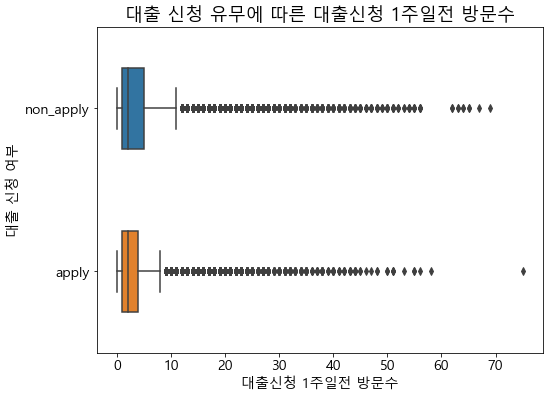

In [186]:
plt.figure(figsize=(8, 6))
ax=sys.boxplot(data=loan_apply_sum2, x="대출신청 1주일전 방문수", y="loan_applied", width=0.5)
plt.xlabel('대출신청 1주일전 방문수',fontsize=14)
plt.ylabel('대출 신청 여부',fontsize=14)  # y축 글자 크기

# y축 카테고리 글자 크기 조정  
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14) 
# x축 눈금 글자 크기 조정
plt.xticks(fontsize=14)
# 제목 추가
plt.title("대출 신청 유무에 따른 대출신청 1주일전 방문수", fontsize=18)
plt.savefig(image_path+"대출 신청 유무에 따른 대출신청 1주일전 방문수_boxplot.png")  # PNG 형식으로 저장

count     49578.000000
mean       2041.788334
std       26846.188783
min           1.000000
25%          30.000000
50%          67.000000
75%         110.000000
max      604083.000000
Name: 대출신청 이전 비활성기간, dtype: float64


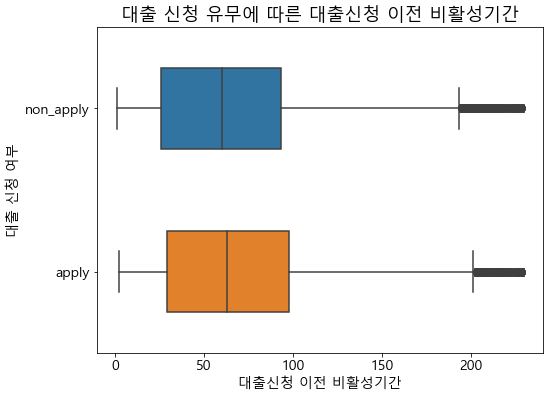

In [189]:
print(loan_apply_sum2["대출신청 이전 비활성기간"].describe())
plt.figure(figsize=(8, 6))
ax = sys.boxplot(data=loan_apply_sum2.loc[loan_apply_sum2["대출신청 이전 비활성기간"]<230], x="대출신청 이전 비활성기간", y="loan_applied", width=0.5)
plt.xlabel('대출신청 이전 비활성기간',fontsize=14)
plt.ylabel('대출 신청 여부',fontsize=14)  # y축 글자 크기

# y축 카테고리 글자 크기 조정  
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14) 
# x축 눈금 글자 크기 조정
plt.xticks(fontsize=14)
# 제목 추가
plt.title("대출 신청 유무에 따른 대출신청 이전 비활성기간", fontsize=18)

#plt.savefig(image_path+"대출 신청 유무에 따른 대출신청 이전 비활성기간_boxplot.png")  # PNG 형식으로 저장

In [154]:
loan_apply_sum2["대출신청 1주일간 평균 체류시간"].describe()

count    53784.000000
mean       140.184266
std        203.515941
min          0.000000
25%         35.000000
50%         81.000000
75%        162.609091
max       3710.000000
Name: 대출신청 1주일간 평균 체류시간, dtype: float64

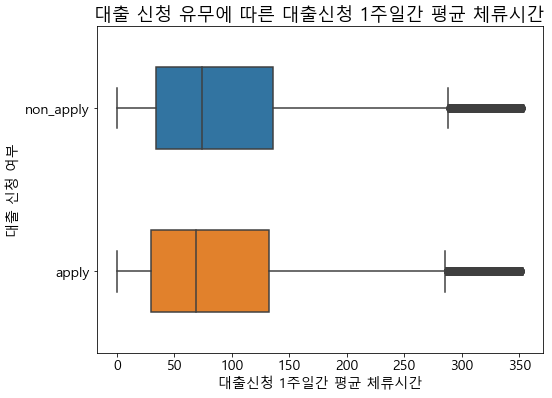

In [192]:
plt.figure(figsize=(8, 6))
ax = sys.boxplot(data=loan_apply_sum2.loc[loan_apply_sum2["대출신청 1주일간 평균 체류시간"]<353.1,:], x="대출신청 1주일간 평균 체류시간", y="loan_applied", width = 0.5)
plt.xlabel('대출신청 1주일간 평균 체류시간',fontsize=14)
plt.ylabel('대출 신청 여부',fontsize=14)  # y축 글자 크기

# y축 카테고리 글자 크기 조정  
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14) 
# x축 눈금 글자 크기 조정
plt.xticks(fontsize=14)
# 제목 추가
plt.title("대출 신청 유무에 따른 대출신청 1주일간 평균 체류시간", fontsize=18)

plt.savefig(image_path+"대출 신청 유무에 따른 대출신청 1주일간 평균 체류시간_boxplot.png")  # PNG 형식으로 저장